# Lab 03: Differentiable Mechanics & Inverse Parameter Identification

**Learning objective.** Formulate a forward mechanics problem in PyTorch, differentiate through the finite-element linear solve, verify the sensitivities against finite differences, and use gradient descent to solve an inverse problem recovering an unknown material stiffness parameter.

**Predict first.** For a fixed positive load, predict the sign of $\mathrm{d}u_{\mathrm{tip}}/\mathrm{d}E$. Also predict whether the notebook's $\exp(\mathrm{log\_E})$ parameterisation imposes an upper bound on the modulus.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

<div class="badge-row">
<a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/03_tiny_derivative_inverse_toy.ipynb"><img src="../_static/colab-badge.svg" alt="Open in Colab"/></a>
<a class="badge-link" href="../../notebooks/study/03_tiny_derivative_inverse_toy.ipynb">Download Practice Notebook</a>
<a class="badge-link" href="../../notebooks/solutions/03_tiny_derivative_inverse_toy.ipynb">Download with Worked Solutions</a>
<a class="badge-link" href="../../SETUP.md">Environment Setup</a>
</div>

In engineering inverse problems, we frequently observe boundary measurements (such as displacements or reaction forces) and wish to infer unknown material parameters (such as Young's modulus $E$ or toughness $G_c$).

In this tutorial, we:
1. Model a one-dimensional elastic bar governed by $\frac{d}{dx}\left(E \frac{du}{dx}\right) + f = 0$.
2. Parameterize the unknown modulus using an unconstrained log-modulus representation $E = \exp(\theta)$ to ensure strict positivity ($E > 0$).
3. Compute the sensitivity of the mean-squared tracking loss $J(E) = \frac{1}{m}\sum_{i=1}^{m}[u_{\mathrm{tip}}(E,F_i)-u_i^\star]^2$ using PyTorch automatic differentiation, where $m=4$ training loads provide the observed tip displacements.
4. Recover the true material parameter $E^\star$ using gradient descent.

In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))


{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.014}


In [2]:
torch.manual_seed(20260909)
n_elements, length, area = 40, 1.0, 1.0
h = length / n_elements
# Unit-modulus stiffness. E remains a differentiable scalar multiplier.
K0 = torch.zeros((n_elements + 1, n_elements + 1), dtype=torch.float64)
local = torch.tensor([[1.0, -1.0], [-1.0, 1.0]], dtype=torch.float64) * area / h
for e in range(n_elements):
    K0[e:e+2, e:e+2] += local

def tip_displacement(E, load):
    K_free = (E * K0)[1:, 1:]
    force = torch.zeros(n_elements, dtype=torch.float64)
    force[-1] = load
    return torch.linalg.solve(K_free, force)[-1]

E_probe = torch.tensor(1.8, dtype=torch.float64, requires_grad=True)
u_probe = tip_displacement(E_probe, 1.1)
(du_dE_ad,) = torch.autograd.grad(u_probe, E_probe)
h_fd = 1.0e-6
du_dE_fd = (tip_displacement(E_probe.detach() + h_fd, 1.1) - tip_displacement(E_probe.detach() - h_fd, 1.1)) / (2*h_fd)
du_dE_exact = -u_probe.detach() / E_probe.detach()
print({"u_tip": float(u_probe.detach()), "AD": float(du_dE_ad), "FD": float(du_dE_fd), "analytic": float(du_dE_exact)})
assert abs(float(du_dE_ad - du_dE_exact)) < 1.0e-12
assert abs(float(du_dE_fd - du_dE_exact)) < 1.0e-8


{'u_tip': 0.6111111111111187, 'AD': -0.33950617283949214, 'FD': -0.3395061727862192, 'analytic': -0.3395061728395104}


In [3]:
# Whole load cases are kept separate: train, validation, and held-out.
E_true = torch.tensor(2.4, dtype=torch.float64)
train_loads = torch.tensor([0.35, 0.75, 1.15, 1.55], dtype=torch.float64)
validation_load = torch.tensor(0.95, dtype=torch.float64)
heldout_load = torch.tensor(1.35, dtype=torch.float64)
observed_train = torch.stack([tip_displacement(E_true, load) for load in train_loads]).detach()
observed_validation = tip_displacement(E_true, validation_load).detach()
observed_heldout = tip_displacement(E_true, heldout_load).detach()

log_E = torch.nn.Parameter(torch.log(torch.tensor(0.9, dtype=torch.float64)))
optimiser = torch.optim.Adam([log_E], lr=0.08)
history = []
for iteration in range(180):
    optimiser.zero_grad(set_to_none=True)
    E_trial = torch.exp(log_E)
    predicted = torch.stack([tip_displacement(E_trial, load) for load in train_loads])
    loss = torch.mean((predicted - observed_train) ** 2)
    loss.backward()
    optimiser.step()
    if iteration % 10 == 0 or iteration == 179:
        with torch.no_grad():
            val_error = abs(tip_displacement(torch.exp(log_E), validation_load) - observed_validation)
        history.append((iteration + 1, float(torch.exp(log_E).detach()), float(loss.detach()), float(val_error)))

E_fit = torch.exp(log_E).detach()
heldout_prediction = tip_displacement(E_fit, heldout_load)
print({"E_true": float(E_true), "E_fit": float(E_fit), "heldout_observed": float(observed_heldout), "heldout_prediction": float(heldout_prediction)})
assert abs(float(E_fit - E_true)) < 2.0e-3


{'E_true': 2.4, 'E_fit': 2.400302387627723, 'heldout_observed': 0.562499999999992, 'heldout_prediction': 0.5624291368281488}


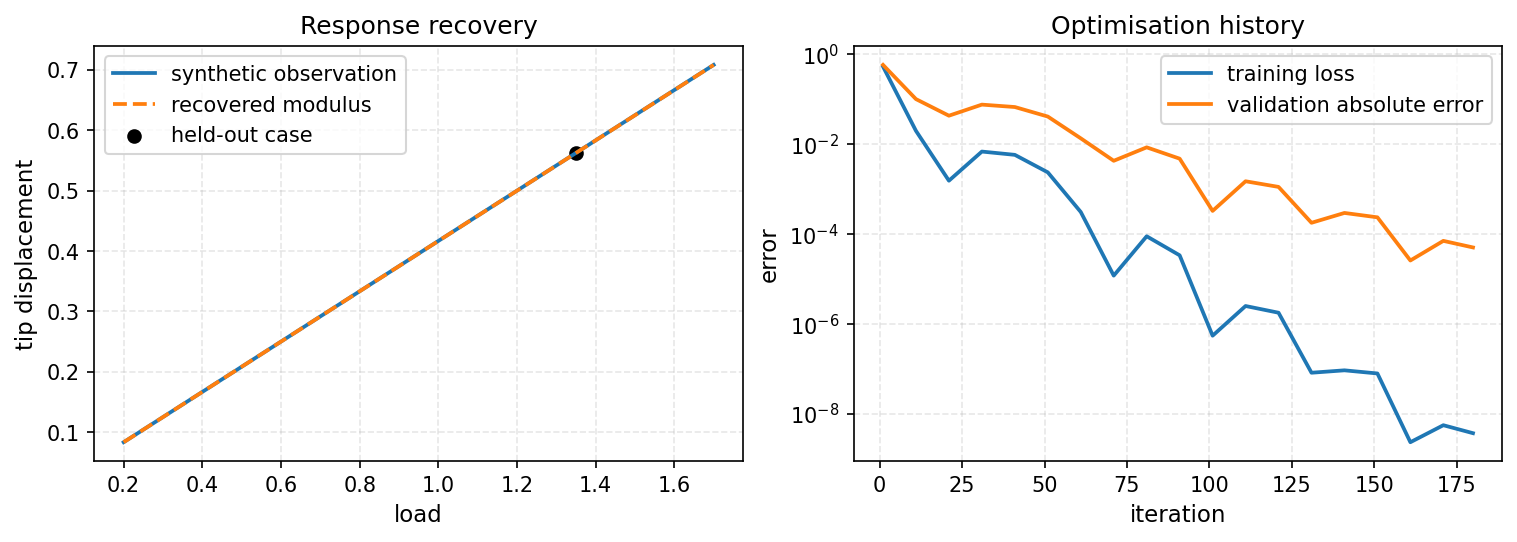

In [4]:
history_array = np.array(history)
response_loads = torch.linspace(0.2, 1.7, 80, dtype=torch.float64)
true_response = np.array([float(tip_displacement(E_true, load)) for load in response_loads])
fit_response = np.array([float(tip_displacement(E_fit, load)) for load in response_loads])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(response_loads, true_response, label="synthetic observation")
axes[0].plot(response_loads, fit_response, "--", label="recovered modulus")
axes[0].scatter([heldout_load], [observed_heldout], color="black", label="held-out case")
axes[0].set(xlabel="load", ylabel="tip displacement", title="Response recovery")
axes[0].legend()
axes[1].semilogy(history_array[:, 0], history_array[:, 2], label="training loss")
axes[1].semilogy(history_array[:, 0], history_array[:, 3], label="validation absolute error")
axes[1].set(xlabel="iteration", ylabel="error", title="Optimisation history")
axes[1].legend()
fig.savefig(assets_dir() / "tiny_inverse_bar.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Toy elastic-bar response recovery and optimisation history.")
plt.close(fig)


Compare the recovered modulus and held-out displacement with their
reference values. The analytic bar sensitivity helps explain the
agreement between automatic differentiation and finite differences.
Extending the calculation to fracture introduces a load-dependent
history, irreversibility constraints and sensitivity to the chosen
observations and solver tolerance.


## Key takeaways

- The elastic-bar response connects stiffness, load and displacement through equilibrium.
- Reverse-mode differentiation propagates a scalar observation or loss back to the chosen parameter.
- Optimising $\log E$ keeps the recovered modulus positive.
- A held-out displacement tests the recovered parameter on an additional observation.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Derive the tip sensitivity

The fixed-left, unit-length, unit-area bar has a tip load $F$ and a uniform modulus $E$.

1. Derive $u_{\mathrm{tip}}(E,F)$ and $\mathrm{d}u_{\mathrm{tip}}/\mathrm{d}E$.
2. Evaluate both at $E=1.8$ and $F=1.1$.
3. Compare with the notebook's autograd and centred-FD values.

::::{admonition} Hint 1
:class: dropdown course-hint

For a uniform axial bar, the series assembly gives $u_{\mathrm{tip}}=FL/(EA)$. Here $L=A=1$.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

For a uniform bar,

$$
u_{\mathrm{tip}}=\frac{FL}{EA},
\qquad
\frac{\partial u_{\mathrm{tip}}}{\partial E}=-\frac{FL}{AE^2}.
$$

With $L=A=1$, $F=1.1$ and $E=1.8$, the tip displacement is approximately $0.611$ and the sensitivity is approximately $-0.340$. A stiffer bar stretches less under the same load. Compare the analytic and computed sensitivities using the relative error and the sign; vary the finite-difference spacing to assess its numerical accuracy.
::::

### Exercise 2: Explore positive stiffness and additional observations

1. Let $z=\log E$. Derive $\partial u_{\mathrm{tip}}/\partial z$ from the chain rule. What values of stiffness can this parameterisation represent?
2. Use `tip_displacement` to compare the recovered and reference bar over several positive loads. Plot both responses and their difference.
3. Explain what an additional load observation tests in this linear bar model. What extra experiment would help if the material response were nonlinear?

::::{admonition} Hint 2
:class: dropdown course-hint

Use $\partial E/\partial z=E$ and the sensitivity from Exercise 1. The notebook supplies `E_fit`, `E_true` and the callable `tip_displacement`.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

The exponential maps each real $z$ to a positive stiffness. Applying the chain rule gives

$$
\frac{\partial u_{\mathrm{tip}}}{\partial z}
=-\frac{FL}{AE^2}E=-u_{\mathrm{tip}}.
$$

```python
loads = torch.linspace(0.2, 1.5, 12, dtype=torch.float64)
with torch.no_grad():
    reference = torch.stack([tip_displacement(E_true, force) for force in loads])
    recovered = torch.stack([tip_displacement(E_fit, force) for force in loads])
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), layout="constrained")
axes[0].plot(loads, reference, label="reference")
axes[0].plot(loads, recovered, "--", label="recovered")
axes[0].set(xlabel="tip load F", ylabel="tip displacement")
axes[0].legend()
axes[1].plot(loads, recovered - reference)
axes[1].set(xlabel="tip load F", ylabel="displacement difference")
display_figure(fig)
```

Both curves are straight lines in this uniform linear-elastic model. An additional load tests the recovered compliance on another observation, while repeated noisy measurements help quantify uncertainty. A nonlinear material would require observations spanning the relevant strain range; unloading measurements could also reveal irreversible response.
::::